# Dropout: A Simple Way to Prevent Neural Networks from Overfitting
**Authors:** Nitish Srivastava, Geoffrey Hinton, Alex Krizhevsky, Ilya Sutskever, Ruslan Salakhutdinov (University of Toronto)

# https://www.jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf?utm_content=buffer79b4

## Abstract
This paper introduces dropout, a regularization technique that randomly drops units (along with their connections) from a neural network during training to prevent overfitting. Dropout can be interpreted as efficiently approximating an exponential model combination: training with dropout samples from an exponential number of different "thinned" sub-networks, and at test time, an approximate averaging effect is achieved using a single unthinned network with appropriately scaled-down weights. The authors demonstrate that dropout significantly improves generalization performance on supervised learning tasks across vision, speech recognition, document classification, and computational biology, achieving state-of-the-art results on multiple benchmark datasets.

## Problems
- Deep neural networks with large numbers of parameters are highly expressive but prone to severe overfitting, especially with limited training data, learning complex relationships that reflect sampling noise rather than true underlying patterns.
- The theoretically optimal way to regularize a fixed-size model — averaging predictions over all possible parameter settings weighted by posterior probability — is computationally infeasible for large networks.
- Standard model combination (training and averaging many separate large neural networks) is prohibitively expensive: it requires substantial computation to train each network, sufficient data to train diverse models, and is too slow to use many models simultaneously at test time.
- Existing regularization methods (early stopping, L1/L2 weight penalties, soft weight sharing) provide only partial solutions to overfitting in large networks.
- Complex co-adaptations between hidden units, where units learn to fix each other's mistakes based on training data, generalize poorly to unseen test data.

## Proposed Solutions
1. **Dropout**: During training, each hidden and visible unit (except output units) is retained with a fixed probability $p$ (typically 0.5 for hidden units, closer to 1 for input units), independently of other units, and dropped otherwise, along with all its connections.
2. **Approximate model averaging via weight scaling**: At test time, instead of explicitly averaging predictions from $2^n$ possible thinned networks, a single network is used with all units present but with outgoing weights multiplied by $p$, producing an output approximately equal to the expected output under the training-time dropout distribution.
3. **Max-norm regularization**: Constrain the norm of the incoming weight vector at each hidden unit to be upper bounded by a constant $c$ (i.e., $\|\mathbf{w}\|_2 \leq c$), imposed by projecting weights back onto a ball of radius $c$ whenever exceeded, combined with large decaying learning rates and high momentum.
4. **Dropout Restricted Boltzmann Machines (Dropout RBMs)**: An extension of dropout to undirected graphical models by augmenting RBMs with a binary random mask vector over hidden units.
5. **Marginalized (deterministic) dropout**: Analytically marginalizing the dropout noise to obtain deterministic regularizers, closed-form for linear regression and approximated via Gaussian assumptions for logistic regression.
6. **Multiplicative Gaussian noise dropout**: An alternative to Bernoulli-distributed dropout masks, multiplying activations by noise drawn from $\mathcal{N}(1, \sigma^2)$ instead of a Bernoulli distribution.

## Purpose
The purpose was to develop a computationally efficient technique that approximates the benefits of combining exponentially many neural network architectures — thereby substantially reducing overfitting — without the prohibitive training and inference costs of training and averaging many separate large networks, and to empirically validate this technique's generality across diverse application domains and network types (feed-forward nets, convolutional nets, RBMs).

## Methodology
- **Model formulation**: For a network with $L$ hidden layers, standard feed-forward computation is:
$$z_i^{(l+1)} = w_i^{(l+1)} y^l + b_i^{(l+1)}, \qquad y_i^{(l+1)} = f(z_i^{(l+1)})$$
With dropout:
$$r_j^{(l)} \sim \text{Bernoulli}(p), \qquad \tilde{y}^{(l)} = r^{(l)} * y^{(l)}, \qquad z_i^{(l+1)} = w_i^{(l+1)} \tilde{y}^{l} + b_i^{(l+1)}, \qquad y_i^{(l+1)} = f(z_i^{(l+1)})$$
where $*$ denotes element-wise multiplication and $r^{(l)}$ is a vector of independent Bernoulli random variables.
- **Test-time weight scaling**: $W^{(l)}_{test} = pW^{(l)}$, ensuring expected output under dropout matches the output of the scaled deterministic network.
- **Training procedure**: Standard stochastic gradient descent (with momentum, annealed learning rates, and L2 weight decay as needed) applied to a randomly sampled thinned sub-network for each training case in each mini-batch; gradients for unused parameters contribute zero for that case.
- **Datasets evaluated**: MNIST (784-dim, 60K/10K), SVHN (3072-dim, 600K/26K), CIFAR-10/CIFAR-100 (3072-dim, 60K/10K), ImageNet ILSVRC-2010/2012 (65536-dim, 1.2M/150K), TIMIT (2520-dim, 1.1M/58K frames), Reuters-RCV1 (2000-dim, 200K/200K), and an Alternative Splicing genetics dataset (1014-dim, 2932/733).
- **Architectures**: Fully-connected networks (2–4 hidden layers, 1024–8192 units per layer) for MNIST; convolutional networks with 3 convolutional layers plus 2 fully-connected layers for SVHN and CIFAR; the Krizhevsky et al. (2012) CNN architecture for ImageNet; multi-layer networks for TIMIT frame classification and Reuters document classification.
- **Dropout RBM formulation**:
$$P(r, h, v; p, \theta) = P(r; p)P(h, v|r; \theta), \qquad P(r; p) = \prod_{j=1}^F p^{r_j}(1-p)^{1-r_j}$$
trained using Contrastive Divergence (CD-1), sampling $r$ before each training case.
- **Marginalized linear regression**: For data matrix $X$ and targets $y$, with dropout retaining each input dimension with probability $p$, the marginalized objective reduces to:
$$\min_{w} \|y - pXw\|^2 + p(1-p)\|\Gamma w\|^2, \qquad \Gamma = (\text{diag}(X^TX))^{1/2}$$
- **Evaluation approach**: Comparison of test classification error (or phone error rate, or Code Quality metric for splicing) with and without dropout, against other regularizers (L2, max-norm, KL-sparsity), against Bayesian neural networks, and via sensitivity analyses across dropout rate $p$, network size, training set size, and number of Monte Carlo samples for model averaging.

## Results

| Dataset | Best Without Dropout | Best With Dropout | Metric |
|---|---|---|---|
| MNIST (feed-forward) | 1.60% (Simard et al., 2003) | 0.79% (DBM-pretrained + dropout) | Test error |
| SVHN (ConvNet) | 3.95% | 2.55% (dropout in all layers) | Test error |
| CIFAR-10 (ConvNet) | 14.98% | 12.61% (dropout in all layers) | Test error |
| CIFAR-100 (ConvNet) | 43.48% | 37.20% (dropout in all layers) | Test error |
| ImageNet ILSVRC-2010 (ConvNet) | 45.7% / 25.7% (SIFT+FV) | 37.5% / 17.0% | Top-1 / Top-5 error |
| ImageNet ILSVRC-2012 (5 ConvNets avg.) | 26.2% (best non-dropout) | 16.4% (test) | Top-5 error |
| TIMIT (6-layer NN) | 23.4% | 21.8% | Phone error rate |
| TIMIT (8-layer, DBN-pretrained) | 20.5%/20.7% | 19.7% | Phone error rate |
| Reuters-RCV1 | 31.05% | 29.62% | Test error |
| Alternative Splicing | 440–487 bits (non-dropout methods) | 567 bits (dropout NN); Bayesian NN: 623 bits | Code Quality |

- On MNIST, dropout combined with max-norm regularization achieved the lowest error (1.05%) among all regularizers compared (L2: 1.62%, max-norm alone: 1.35%, dropout+L2: 1.25%, dropout+max-norm: 1.05%).
- Dropout's benefit persisted robustly across many different network architectures without architecture-specific hyperparameter tuning (Figure 4), and applying dropout to convolutional layers (not just fully connected layers) provided additional gains despite convolutional layers having relatively few parameters, attributed to dropout providing noisy inputs that regularize higher fully-connected layers.
- Dropout increased sparsity of hidden unit activations as a side effect, even without explicit sparsity-inducing regularizers; mean activation dropped from ~2.0 (without dropout) to ~0.7 (with dropout, $p=0.5$) on MNIST autoencoders.
- Optimal dropout rate $p$ for hidden units was found in the range 0.4–0.8, with $p=0.5$ close to optimal in most settings; small $p$ with fixed network size caused underfitting.
- Dropout's benefit increased with dataset size up to a point before declining: on extremely small datasets (100–500 examples), dropout provided no improvement, while on very large datasets the relative improvement also diminished, indicating a "sweet spot" for dataset size.
- Weight scaling closely approximated true Monte Carlo model averaging: around $k=50$ sampled thinned networks were needed for Monte Carlo averaging to match the accuracy of the efficient weight-scaling approximation.
- Dropout RBMs produced qualitatively coarser but less "dead"-unit-prone features than standard RBMs, and similarly induced sparser hidden unit activations.
- Feature visualization (MNIST autoencoders) showed dropout-trained hidden units learned individually meaningful, edge/stroke/spot-detecting features, whereas non-dropout units exhibited entangled, co-adapted, less interpretable features.
- Comparison with Bayesian neural networks on the small Alternative Splicing dataset showed Bayesian networks (623 bits) outperformed dropout (567 bits), though dropout substantially outperformed standard non-Bayesian methods, illustrating dropout as a fast, more scalable but slightly less accurate approximation to full Bayesian model averaging.
- A key practical limitation: dropout networks typically require 2–3 times longer training time than standard networks of the same architecture, due to noisier gradient updates from training different random sub-architectures at each step.

## Conclusions
Dropout is established as a simple, computationally efficient, and broadly applicable regularization technique that substantially improves neural network generalization by preventing complex co-adaptations among hidden units through random unit removal during training and approximate geometric-mean model averaging at test time. The technique proved effective and largely architecture-agnostic across vision (achieving state-of-the-art results on SVHN, ImageNet, CIFAR-10/100, MNIST), speech recognition, text classification, and genomics tasks, and extends naturally to graphical models such as RBMs. While dropout does not match the theoretically superior performance of full Bayesian model averaging on small datasets, it offers a far more scalable and practical alternative for large networks and datasets. The primary cost of dropout is increased training time due to gradient noise, motivating the paper's exploration of marginalized (deterministic) dropout variants as a promising direction for future work to retain dropout's regularization benefits while reducing training time.

# Mathematical and Statistical Content in "Dropout: A Simple Way to Prevent Neural Networks from Overfitting"

## 1. Standard Feed-Forward Network Equations

$$z_i^{(l+1)} = w_i^{(l+1)} y^{l} + b_i^{(l+1)}, \qquad y_i^{(l+1)} = f\left(z_i^{(l+1)}\right)$$

- $y^{(l)}$: output vector of layer $l$ (with $y^{(0)} = x$, the input).
- $z^{(l+1)}$: pre-activation input to layer $l+1$.
- $W^{(l)}, b^{(l)}$: weights and biases at layer $l$.
- $f$: activation function, e.g. the logistic sigmoid $f(x) = 1/(1+e^{-x})$.

**Role:** This is the baseline computation of a standard multilayer neural network, against which the dropout-modified computation is contrasted.

## 2. Dropout Feed-Forward Equations

$$r_j^{(l)} \sim \text{Bernoulli}(p)$$
$$\tilde{y}^{(l)} = r^{(l)} * y^{(l)}$$
$$z_i^{(l+1)} = w_i^{(l+1)} \tilde{y}^{l} + b_i^{(l+1)}, \qquad y_i^{(l+1)} = f\left(z_i^{(l+1)}\right)$$

- $r^{(l)}$: a vector of independent Bernoulli random variables, each equal to 1 with probability $p$ (the retention probability).
- $*$: element-wise (Hadamard) product.
- $\tilde{y}^{(l)}$: the "thinned" output of layer $l$ after dropout masking.

**Role:** This is the core mathematical definition of dropout — at each layer, a random binary mask zeroes out a subset of unit outputs before they are passed to the next layer. Applied at every layer, this amounts to sampling a random sub-network (a "thinned network") from the full architecture for each training case.

## 3. Test-Time Weight Scaling

$$W^{(l)}_{test} = p W^{(l)}$$

**Role:** Since it is computationally infeasible to explicitly average predictions across all $2^n$ possible thinned networks at test time, the paper proposes this approximation: use the full (un-thinned) network but scale down each unit's outgoing weights by $p$. This ensures that the *expected* output of a unit under the training-time dropout distribution matches its output at test time, allowing an exponential ensemble of weight-sharing models to be approximated by a single forward pass.

## 4. Network as a Collection of $2^n$ Thinned Models

A network with $n$ units can be viewed as a collection of $2^n$ possible thinned sub-networks, all sharing weights so that the total number of distinct parameters remains $O(n^2)$ or less.

**Role:** This combinatorial framing is the conceptual foundation of dropout: rather than training $2^n$ separate models (computationally intractable), dropout trains a shared-weight ensemble implicitly, with each thinned network trained rarely (often just once or not at all) but contributing to a common parameter set.

## 5. Max-Norm Regularization

$$\|\mathbf{w}\|_2 \leq c$$

- $\mathbf{w}$: the vector of weights incoming to any hidden unit.
- $c$: a fixed constant (tunable hyperparameter, typically 3–4).

**Role:** This constrains the Euclidean norm of each hidden unit's incoming weight vector, enforced by projecting $\mathbf{w}$ back onto a ball of radius $c$ whenever it exceeds this bound during optimization. Empirically, combining max-norm regularization with dropout and high learning rates/momentum gave the paper's best generalization results, since bounding the weights allows safe use of large learning rates without risk of weight explosion.

## 6. Dropout Restricted Boltzmann Machine (RBM) Model

Standard RBM joint distribution:
$$P(h, v; \theta) = \frac{1}{Z(\theta)} \exp(v^T W h + a^T h + b^T v)$$

Dropout RBM joint distribution, with mask $r \in \{0,1\}^F$:
$$P(r, h, v; p, \theta) = P(r; p) \, P(h, v \mid r; \theta)$$
$$P(r; p) = \prod_{j=1}^{F} p^{r_j}(1-p)^{1-r_j}$$
$$P(h, v \mid r; \theta) = \frac{1}{Z'(\theta, r)} \exp(v^T W h + a^T h + b^T v) \prod_{j=1}^{F} g(h_j, r_j)$$
$$g(h_j, r_j) = \mathbb{1}(r_j = 1) + \mathbb{1}(r_j = 0)\mathbb{1}(h_j = 0)$$

with the conditional distributions:
$$P(h_j = 1 \mid r_j, v) = \mathbb{1}(r_j=1)\,\sigma\left(b_j + \sum_i W_{ij} v_i\right)$$
$$P(v_i = 1 \mid h) = \sigma\left(a_i + \sum_j W_{ij} h_j\right)$$

- $\sigma(\cdot)$: the logistic sigmoid function.
- $g(h_j, r_j)$: an indicator function forcing $h_j = 0$ whenever $r_j = 0$ (i.e., dropped hidden units are excluded).

**Role:** This extends dropout to undirected graphical models. The Dropout RBM can be interpreted as a mixture of exponentially many standard RBMs sharing weights, each using a different random subset of hidden units, analogous to dropout's effect in feed-forward networks. Learning uses standard Contrastive Divergence (CD-1), applied only to the retained (unmasked) hidden units.

## 7. Marginalized Dropout for Linear Regression

Standard linear regression objective:
$$\min_{w} \|y - Xw\|^2$$

With dropout applied to inputs (each column retained with probability $p$, represented by random matrix $R$ with $R_{ij} \sim \text{Bernoulli}(p)$):
$$\min_{w} \; \mathbb{E}_{R \sim \text{Bernoulli}(p)}\left[\|y - (R * X)w\|^2\right]$$

This expectation reduces in closed form to:
$$\min_{w} \; \|y - pXw\|^2 + p(1-p)\|\Gamma w\|^2, \qquad \Gamma = \left(\text{diag}(X^T X)\right)^{1/2}$$

Equivalently, absorbing $p$ into $\tilde{w} = pw$:
$$\min_{\tilde{w}} \; \|y - X\tilde{w}\|^2 + \frac{1-p}{p}\|\Gamma \tilde{w}\|^2$$

**Role:** This is a key theoretical result showing that, in expectation, dropout applied to linear regression is mathematically equivalent to a form of ridge regression (L2 regularization), but with feature-specific regularization strength scaled by each input dimension's variance ($\Gamma$). This provides an analytical, deterministic (noise-free) understanding of what dropout is implicitly doing as a regularizer in the simplest possible model, and shows explicitly how the regularization strength depends on the dropout rate $p$ (stronger regularization as $p$ decreases, i.e., more aggressive dropout).

## 8. Marginalization for Logistic Regression / Deep Networks

For logistic regression, an exact closed-form marginalized objective is intractable, but under a Gaussian approximation to the distribution of pre-activation inputs and their gradients, the mean and variance can be computed efficiently, enabling approximate marginalization (Wang and Manning, 2013, cited and extended upon).

**Role:** This shows the linear regression result does not generalize exactly to nonlinear models, motivating the use of approximate (Gaussian-based) marginalization as a faster alternative to Monte Carlo dropout sampling, though the underlying assumptions weaken as more layers are added.

## 9. Multiplicative Gaussian Noise Dropout

Standard Bernoulli-masked activation:
$$h_i \cdot r_b, \qquad r_b = \begin{cases} 1/p & \text{with probability } p \\ 0 & \text{with probability } 1-p \end{cases}, \qquad \mathbb{E}[r_b] = 1, \; \text{Var}[r_b] = \frac{1-p}{p}$$

Gaussian alternative:
$$h_i \cdot r_g, \qquad r_g \sim \mathcal{N}(1, \sigma^2), \qquad \sigma^2 = \frac{1-p}{p}$$

**Role:** This generalizes dropout beyond Bernoulli noise to continuous multiplicative Gaussian noise with matched mean (1) and variance ($(1-p)/p$). Because the expected activation is unchanged, no weight rescaling is needed at test time. The paper notes that, given matched first and second moments, the Gaussian noise distribution has the *highest entropy* while the Bernoulli distribution has the *lowest*, and found the higher-entropy Gaussian variant performed comparably or slightly better in practice (Table 10).

## 10. Statistical Evaluation Metrics

- **Classification/test error (%)**: the primary metric for MNIST, SVHN, CIFAR-10/100, ImageNet, used throughout Tables 2–4, 9.
- **Top-1 and Top-5 error rate**: for ImageNet, top-5 error is the fraction of test images for which the correct label is not among the model's five most probable predicted labels (Tables 5–6).
- **Phone error rate**: for TIMIT speech recognition (Table 7), the fraction of incorrectly classified phone frames.
- **Code Quality metric** (Alternative Splicing dataset):
$$\text{Code Quality} = \sum_{i=1}^{|\text{data points}|} \sum_{t \in \text{tissue types}} \sum_{s \in \{\text{inc, exc, nc}\}} p^s_{i,t} \log\left(\frac{q^s_t(r_i)}{\bar{p}^s}\right)$$
where $p^s_{i,t}$ is the target probability for state $s$/tissue $t$ in example $i$, $q^s_t(r_i)$ is the model's predicted probability, and $\bar{p}^s$ is the average target probability for state $s$ across all data. This is effectively a negative KL-divergence-based scoring metric (higher is better), used because the task involves predicting a probability distribution over three biological states rather than a single class label.

## 11. Statistical Experimental Design

- **Held-out validation sets**: e.g., 10,000 images held from MNIST training set, 5,000 from CIFAR training sets, for hyperparameter tuning before final training on combined train+validation data.
- **k-fold-style averaging**: Alternative Splicing results averaged over 5 folds (matching prior work by Xiong et al., 2011).
- **Averaging over random seeds**: Gaussian vs. Bernoulli dropout comparison (Table 10) averaged over 10 different random seeds to reduce variance in reported error rates.
- **Monte Carlo estimation of the true model average**: the paper empirically evaluates, for increasing sample counts $k$, the classification error of averaging $k$ randomly sampled dropout sub-networks' predictions, showing convergence toward (and slightly surpassing) the weight-scaling approximation as $k \to \infty$ (Figure 11) — a direct empirical validation of the weight-scaling approximation's statistical validity.

## 12. Network Capacity Scaling Heuristic

$$\text{effective units after dropout} \approx pn$$

where $n$ is the total number of units in a layer and $p$ is the retention probability.

**Role:** This simple relation (Appendix A.1) is used as a practical heuristic: since only $pn$ units are present in expectation after dropout, a layer that would optimally have $n$ units in a standard (non-dropout) network should be sized at least $n/p$ units when using dropout, to compensate for the reduced effective capacity during training.

## Summary of Statistical Practice
The paper's mathematical contributions center on two threads: (1) a stochastic regularization mechanism (Bernoulli or Gaussian multiplicative noise on activations) justified as an efficient approximation to exponential model averaging, with a rigorous test-time expectation-matching argument (weight scaling); and (2) closed-form or approximate analytical marginalization of this stochastic noise, which reveals dropout's deep connection to classical L2/ridge regularization in the simplest linear case, providing theoretical grounding for its practical, empirically-validated success across all reported experimental domains.

# Problems, Limitations, and Proposed Solutions in "Dropout: A Simple Way to Prevent Neural Networks from Overfitting"

| # | Key Problem / Research Gap | How This Limited Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Deep neural networks with large numbers of parameters overfit severely, especially with limited training data, learning relationships that reflect sampling noise rather than true patterns | Existing regularization methods (early stopping, L1/L2 weight penalties, soft weight sharing) provided only partial protection against overfitting in large, highly expressive networks | Introduce dropout, which randomly removes units and their connections during training, preventing complex co-adaptations between hidden units that do not generalize to unseen data |
| 2 | The theoretically optimal regularization approach — Bayesian averaging over all possible parameter settings weighted by posterior probability — is computationally infeasible for large models | This left practitioners without a practical way to approach the "Bayesian gold standard" of model averaging for large neural networks | Approximate an equally weighted geometric mean of predictions from an exponential number of models that share parameters, achieved through the dropout training procedure |
| 3 | Combining predictions from many independently trained large neural networks (ensembling) is prohibitively expensive in both training time and test-time inference | Training many different architectures requires extensive hyperparameter search and computation per model; using all trained models at test time is infeasible when fast responses are needed | Dropout implicitly trains an exponential collection ($2^n$) of weight-sharing "thinned" sub-networks during a single training run, avoiding the need to train or store separate models |
| 4 | It was unclear how to efficiently approximate the combined predictions of exponentially many thinned networks at test time without expensive Monte Carlo sampling | Explicit averaging of predictions from many sampled sub-networks would be computationally costly at inference time, undermining practicality for real-world deployment | Propose a simple weight-scaling approximation: use a single unthinned network at test time with weights multiplied by the retention probability $p$, shown empirically (via Monte Carlo comparison) to closely match the true model average |
| 5 | Prior noise-injection regularization techniques, such as Denoising Autoencoders (Vincent et al., 2008, 2010), applied noise primarily to input units in unsupervised settings | This limited the applicability of noise-based regularization to unsupervised feature learning and input-layer corruption, without extending the idea to hidden layers or supervised learning broadly | Extend noise injection to all hidden layers of a network and demonstrate its effectiveness across supervised learning tasks in multiple domains (vision, speech, text, genetics), not just unsupervised pretraining |
| 6 | It was unclear whether large networks trained with strong regularization would require careful, network-specific hyperparameter tuning to benefit from regularization | This could limit the practical generality of any proposed regularizer, requiring extensive per-architecture tuning to be useful | Show empirically that dropout provides substantial improvement across many different architectures (varying depth and width) using the same fixed dropout hyperparameters, demonstrating robustness without architecture-specific tuning |
| 7 | The relationship between dropout (a stochastic regularization technique) and standard deterministic regularizers (e.g., L2/ridge regression) was not well understood theoretically | Without this connection, dropout's effectiveness lacked a clear theoretical grounding beyond its intuitive motivation from evolutionary biology and empirical observation | Analytically derive, for the case of linear regression, that dropout is equivalent in expectation to a modified form of L2 (ridge) regularization with feature-specific scaling, providing theoretical justification for dropout's regularizing effect |
| 8 | Standard neural network training does not inherently produce sparse, individually interpretable hidden unit representations; units often co-adapt in ways that are difficult to interpret | Complex co-adaptations among hidden units, while effective for minimizing training loss, do not correspond to meaningful, generalizable features, complicating both interpretability and generalization | Demonstrate that dropout, as a side effect, induces sparser and more interpretable hidden unit activations (e.g., edge/stroke detectors on MNIST) even without explicit sparsity-inducing regularizers |
| 9 | Dropout's applicability had been explored mainly for feed-forward supervised networks; its extension to undirected graphical models such as Restricted Boltzmann Machines (RBMs) was unestablished | This left a gap in whether the co-adaptation-reducing benefits of dropout could transfer to generative, undirected graphical models used for unsupervised feature learning and pretraining | Introduce the Dropout RBM, formally extending the stochastic masking framework to RBMs and empirically showing it produces sparser representations and fewer "dead" units compared to standard RBMs |
| 10 | Dropout, as a stochastic (Monte Carlo) technique, requires random sampling at each training step, increasing training time (2-3x slower) compared to standard training due to noisy gradient updates | This creates a practical trade-off between the regularization benefits of dropout and increased computational/training cost, which was not addressed by a deterministic alternative | Explore marginalizing out the dropout noise analytically to obtain deterministic regularizers that achieve similar effects without stochastic sampling, providing exact results for linear regression and approximate results (via Gaussian assumptions) for logistic regression, as a direction for faster training |
| 11 | It was unknown how dropout's benefit varies with training set size, network size, and the dropout rate hyperparameter $p$, making it unclear how to apply dropout effectively in different data regimes | Without this understanding, practitioners lacked guidance on when dropout would help versus provide no benefit, or how to size networks and tune $p$ appropriately | Conduct systematic experiments varying dataset size, network size (fixed vs. proportionally scaled), and dropout rate $p$, finding a "sweet spot" for dataset size and establishing the heuristic that dropout networks should use approximately $n/p$ units to match the effective capacity of a standard $n$-unit network |

In [1]:
# ============================================================
# Simplified Educational Replication of Core Ideas from:
# "Dropout: A Simple Way to Prevent Neural Networks from Overfitting"
# (Srivastava, Hinton, Krizhevsky, Sutskever, Salakhutdinov, 2014)
#
# This replication directly tests the paper's central claim by training
# the SAME CNN architecture under two conditions:
#   1) WITHOUT Dropout (standard training, prone to overfitting)
#   2) WITH Dropout (p=0.5 in fully-connected layers, as recommended
#      in the paper) plus weight scaling at test time (implemented
#      automatically by PyTorch's nn.Dropout during eval() mode)
#
# Dataset: CIFAR-10 loaded exclusively from HuggingFace
# Framework: PyTorch
# NOTE: This code is provided for copy/paste into a notebook.
# It is NOT executed here.
# ============================================================

# ---- Imports ----
import io
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
from IPython.display import display, Image as IPImage

In [2]:
# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ------------------------------------------------------------
# 2. Class names (CIFAR-10, exact order — labels 0-9)
# ------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ------------------------------------------------------------
# 3. Load CIFAR-10 from HuggingFace (mandatory source)
# ------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

In [5]:
# ------------------------------------------------------------
# 4. Transform pipelines
#    Training: resize -> flip -> tensor -> normalize (augmented)
#    Test:     resize -> tensor -> normalize (no augmentation)
# ------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

In [6]:
# ------------------------------------------------------------
# 5. Custom PyTorch Dataset wrapping the HuggingFace split
# ------------------------------------------------------------
class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split so it behaves like a normal
    PyTorch Dataset: reads the PIL image from the 'img' field,
    ensures RGB mode, applies a torchvision transform, and returns
    (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        image = sample["img"]              # PIL Image
        if image.mode != "RGB":
            image = image.convert("RGB")   # ensure 3 channels
        image = self.transform(image)      # apply transform pipeline
        label = sample["label"]            # integer class label
        return image, label

In [7]:
# ------------------------------------------------------------
# 6. Build full datasets, then take small educational subsets
# ------------------------------------------------------------
full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

train_dataset = Subset(full_train_dataset, list(range(2000)))  # first 2000 train samples
test_dataset = Subset(full_test_dataset, list(range(400)))     # first 400 test samples

In [8]:
# ------------------------------------------------------------
# 7. DataLoaders
# ------------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [9]:
# ------------------------------------------------------------
# 8. Sanity check
# ------------------------------------------------------------
print("=" * 60)
print("SANITY CHECK")
print("=" * 60)
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples:     {len(test_dataset)}")

sample_images, sample_labels = next(iter(train_loader))
print(f"Shape of one batch of images: {sample_images.shape}")
print(f"Label range: min={sample_labels.min().item()}, max={sample_labels.max().item()}")
first_eight_names = [CLASS_NAMES[l.item()] for l in sample_labels[:8]]
print(f"First 8 class names in batch: {first_eight_names}")
print("=" * 60)

SANITY CHECK
Number of training samples: 2000
Number of test samples:     400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: min=0, max=9
First 8 class names in batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [10]:
# ------------------------------------------------------------
# 9. CNN architecture with OPTIONAL Dropout in fully-connected layers
#    (Core idea from the paper: randomly drop hidden units with
#     probability 1-p during training; PyTorch's nn.Dropout
#     automatically implements the paper's test-time weight-scaling
#     trick internally when the model is switched to .eval() mode.)
# ------------------------------------------------------------
class DropoutCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, use_dropout=True, p=0.5):
        super(DropoutCNN, self).__init__()
        self.use_dropout = use_dropout

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 16 -> 8
        )

        # Fully-connected classifier. Dropout (p=0.5) is applied to
        # the hidden fully-connected layer, following the paper's
        # recommendation of p=0.5 for hidden units. If use_dropout is
        # False, dropout layers become identity operations (p=0.0).
        drop_p = p if use_dropout else 0.0
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=drop_p),                 # Dropout on flattened conv features
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=drop_p),                 # Dropout on hidden FC layer
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
# ------------------------------------------------------------
# 10. Training/evaluation routine (reusable for each condition)
# ------------------------------------------------------------
def train_one_setting(setting_name, use_dropout, num_epochs=5):
    """
    Trains a fresh DropoutCNN either with or without dropout.
    PyTorch automatically:
      - applies the random Bernoulli masking during model.train()
      - applies the paper's weight-scaling equivalent during
        model.eval() (dropout layers become a no-op with outputs
        already correctly scaled by the inverted-dropout convention)
    """
    model = DropoutCNN(num_classes=NUM_CLASSES, use_dropout=use_dropout, p=0.5).to(device)

    criterion = nn.CrossEntropyLoss()
    # Following the paper's guidance that dropout benefits from higher
    # momentum; we use a modestly higher momentum for the dropout run.
    momentum_val = 0.95 if use_dropout else 0.9
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=momentum_val)

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []
    per_class_acc_hist = []

    for epoch in range(num_epochs):
        # ---- Training phase ----
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss_hist.append(running_loss / total_train)
        train_acc_hist.append(correct_train / total_train)

        # ---- Validation phase ----
        model.eval()  # dropout layers switch to the paper's scaled, deterministic mode
        val_running_loss, correct_val, total_val = 0.0, 0, 0
        class_correct = np.zeros(NUM_CLASSES)
        class_total = np.zeros(NUM_CLASSES)
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)
                for label, pred in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
                    class_total[label] += 1
                    if label == pred:
                        class_correct[label] += 1

        val_loss_hist.append(val_running_loss / total_val)
        val_acc_hist.append(correct_val / total_val)
        epoch_pc_acc = np.divide(class_correct, class_total,
                                  out=np.zeros_like(class_correct), where=class_total != 0)
        per_class_acc_hist.append(epoch_pc_acc)

        print(f"[{setting_name}] Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss_hist[-1]:.4f} | Train Acc: {train_acc_hist[-1]:.4f} | "
              f"Val Loss: {val_loss_hist[-1]:.4f} | Val Acc: {val_acc_hist[-1]:.4f}")

    return {
        "name": setting_name,
        "model": model,
        "train_loss": train_loss_hist,
        "val_loss": val_loss_hist,
        "train_acc": train_acc_hist,
        "val_acc": val_acc_hist,
        "per_class_acc": per_class_acc_hist,
    }

In [12]:
# ------------------------------------------------------------
# 11. Train under two conditions: WITHOUT dropout vs WITH dropout
#     (the paper's core experimental comparison)
# ------------------------------------------------------------
NUM_EPOCHS = 5

results_no_dropout = train_one_setting("No Dropout", use_dropout=False, num_epochs=NUM_EPOCHS)
results_dropout = train_one_setting("Dropout (p=0.5)", use_dropout=True, num_epochs=NUM_EPOCHS)

all_results = [results_no_dropout, results_dropout]

[No Dropout] Epoch [1/5] Train Loss: 2.2759 | Train Acc: 0.1460 | Val Loss: 2.1876 | Val Acc: 0.2325
[No Dropout] Epoch [2/5] Train Loss: 2.0999 | Train Acc: 0.2345 | Val Loss: 2.0751 | Val Acc: 0.2750
[No Dropout] Epoch [3/5] Train Loss: 1.9933 | Train Acc: 0.2820 | Val Loss: 1.8805 | Val Acc: 0.3300
[No Dropout] Epoch [4/5] Train Loss: 1.8728 | Train Acc: 0.3195 | Val Loss: 1.7867 | Val Acc: 0.3550
[No Dropout] Epoch [5/5] Train Loss: 1.7453 | Train Acc: 0.3800 | Val Loss: 1.6918 | Val Acc: 0.4050
[Dropout (p=0.5)] Epoch [1/5] Train Loss: 2.2870 | Train Acc: 0.1395 | Val Loss: 2.2093 | Val Acc: 0.1950
[Dropout (p=0.5)] Epoch [2/5] Train Loss: 2.1334 | Train Acc: 0.2295 | Val Loss: 2.0846 | Val Acc: 0.2900
[Dropout (p=0.5)] Epoch [3/5] Train Loss: 2.0273 | Train Acc: 0.2660 | Val Loss: 1.9612 | Val Acc: 0.2800
[Dropout (p=0.5)] Epoch [4/5] Train Loss: 1.9344 | Train Acc: 0.2925 | Val Loss: 1.8685 | Val Acc: 0.3425
[Dropout (p=0.5)] Epoch [5/5] Train Loss: 1.7987 | Train Acc: 0.3510 | 

In [13]:
# ------------------------------------------------------------
# 12. Pick the BEST-performing setting (by best val accuracy) as the
#     "primary" model for confusion matrix / confidence / sample panels
# ------------------------------------------------------------
best_result = max(all_results, key=lambda r: max(r["val_acc"]))
best_model = best_result["model"]

best_model.eval()
all_preds, all_labels, all_confidences, all_images_sample = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images_gpu = images.to(device)
        outputs = best_model(images_gpu)
        probs = torch.softmax(outputs, dim=1)
        confidences, predicted = torch.max(probs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confidences.extend(confidences.cpu().numpy())

        if len(all_images_sample) < 8:
            for img in images[:8]:
                all_images_sample.append(img)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)

correct_mask = all_preds == all_labels
mean_conf_correct = all_confidences[correct_mask].mean() if correct_mask.sum() > 0 else 0.0
mean_conf_incorrect = all_confidences[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0.0

In [14]:
# ------------------------------------------------------------
# 13. Compute final metrics for the dashboard
# ------------------------------------------------------------
best_val_epoch = int(np.argmax(best_result["val_acc"])) + 1
best_val_acc = max(best_result["val_acc"])

total_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

final_per_class_acc = best_result["per_class_acc"][-1]
top_classes_idx = np.argsort(final_per_class_acc)[::-1][:3]
low_classes_idx = np.argsort(final_per_class_acc)[:3]
top_classes = [CLASS_NAMES[i] for i in top_classes_idx]
low_classes = [CLASS_NAMES[i] for i in low_classes_idx]

cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

Text(0.5, 0.98, 'Dropout Regularization Study on CIFAR-10 (HuggingFace) — Educational Dashboard')

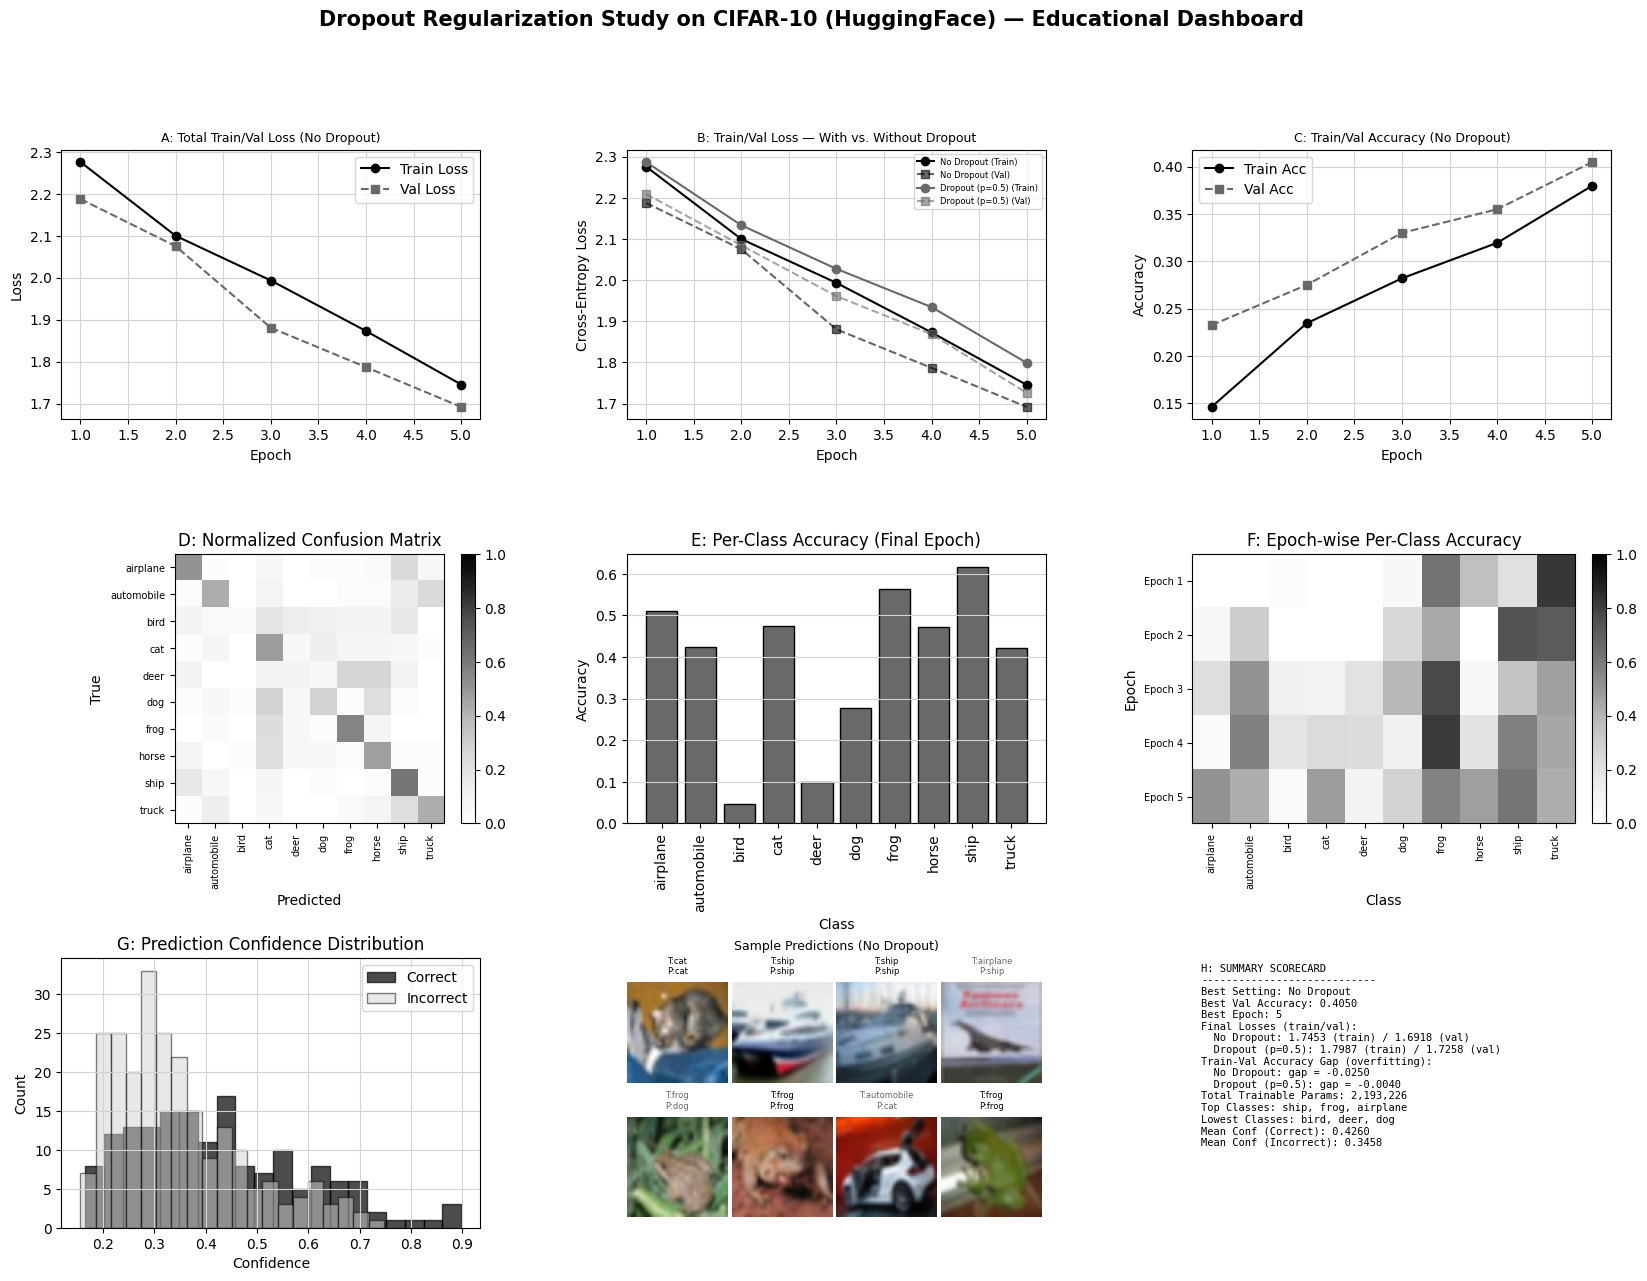

In [15]:
# ------------------------------------------------------------
# 14. Dashboard — white theme enforced globally and per-axis
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "lightgrey",
})

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

epochs_range = np.arange(1, NUM_EPOCHS + 1)

# ---- Panel A: Total training/validation loss (best setting) ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, best_result["train_loss"], marker="o", color="black", label="Train Loss")
axA.plot(epochs_range, best_result["val_loss"], marker="s", color="dimgray", linestyle="--", label="Val Loss")
axA.set_title(f"A: Total Train/Val Loss ({best_result['name']})", color="black", fontsize=9)
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black")
axA.grid(color="lightgrey")

# ---- Panel B: Component-specific loss curves ----
# The paper's central comparison is WITH vs WITHOUT dropout. Each
# condition's train/val loss gap is the key diagnostic for overfitting,
# so both settings' loss curves are shown as dedicated sub-components,
# directly reflecting the paper's core experimental design.
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
for r, ls_train, ls_val, color in [
    (results_no_dropout, "-", "--", "black"),
    (results_dropout, "-", "--", "dimgray"),
]:
    axB.plot(epochs_range, r["train_loss"], marker="o", linestyle=ls_train,
             color=color, label=f"{r['name']} (Train)")
    axB.plot(epochs_range, r["val_loss"], marker="s", linestyle=ls_val,
             color=color, alpha=0.6, label=f"{r['name']} (Val)")
axB.set_title("B: Train/Val Loss — With vs. Without Dropout", color="black", fontsize=9)
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Cross-Entropy Loss", color="black")
axB.legend(labelcolor="black", fontsize=6)
axB.grid(color="lightgrey")

# ---- Panel C: Training/validation accuracy (best setting) ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, best_result["train_acc"], marker="o", color="black", label="Train Acc")
axC.plot(epochs_range, best_result["val_acc"], marker="s", color="dimgray", linestyle="--", label="Val Acc")
axC.set_title(f"C: Train/Val Accuracy ({best_result['name']})", color="black", fontsize=9)
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black")
axC.grid(color="lightgrey")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(cm_normalized, cmap="Greys", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, final_per_class_acc, color="dimgray", edgecolor="black")
axE.set_title("E: Per-Class Accuracy (Final Epoch)", color="black")
axE.set_xlabel("Class", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.tick_params(axis="x", rotation=90, colors="black")
axE.tick_params(axis="y", colors="black")
axE.grid(color="lightgrey", axis="y")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.array(best_result["per_class_acc"])  # shape (NUM_EPOCHS, NUM_CLASSES)
imF = axF.imshow(heatmap_data, cmap="Greys", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black")
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Epoch {e}" for e in epochs_range], color="black", fontsize=7)
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbarF.ax.axes, "yticklabels"), color="black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(all_confidences[correct_mask], bins=20, alpha=0.7, color="black",
         label="Correct", edgecolor="black")
axG.hist(all_confidences[~correct_mask], bins=20, alpha=0.5, color="lightgrey",
         label="Incorrect", edgecolor="black")
axG.set_title("G: Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(color="lightgrey")

# ---- Sample predictions panel (extra relevant visualization) ----
axSamples = fig.add_subplot(gs[2, 1])
axSamples.axis("off")
axSamples.set_title(f"Sample Predictions ({best_result['name']})", color="black", fontsize=9)

def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = std * img + mean
    return np.clip(img, 0, 1)

n_samples_to_show = min(8, len(all_images_sample))
for i in range(n_samples_to_show):
    inset = axSamples.inset_axes([
        (i % 4) * 0.25, 0.5 - (i // 4) * 0.5, 0.24, 0.45
    ])
    img_disp = denormalize(all_images_sample[i])
    inset.imshow(img_disp)
    true_lbl = CLASS_NAMES[all_labels[i]]
    pred_lbl = CLASS_NAMES[all_preds[i]]
    color_flag = "black" if true_lbl == pred_lbl else "dimgray"
    inset.set_title(f"T:{true_lbl}\nP:{pred_lbl}", fontsize=6, color=color_flag)
    inset.axis("off")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 2])
axH.axis("off")

final_loss_lines = "\n".join(
    [f"  {r['name']}: {r['train_loss'][-1]:.4f} (train) / {r['val_loss'][-1]:.4f} (val)"
     for r in all_results]
)

# Compute the train/val gap (overfitting indicator) for both settings
gap_lines = "\n".join(
    [f"  {r['name']}: gap = {(r['train_acc'][-1] - r['val_acc'][-1]):.4f}"
     for r in all_results]
)

scorecard_text = (
    "H: SUMMARY SCORECARD\n"
    "----------------------------\n"
    f"Best Setting: {best_result['name']}\n"
    f"Best Val Accuracy: {best_val_acc:.4f}\n"
    f"Best Epoch: {best_val_epoch}\n"
    f"Final Losses (train/val):\n{final_loss_lines}\n"
    f"Train-Val Accuracy Gap (overfitting):\n{gap_lines}\n"
    f"Total Trainable Params: {total_params:,}\n"
    f"Top Classes: {', '.join(top_classes)}\n"
    f"Lowest Classes: {', '.join(low_classes)}\n"
    f"Mean Conf (Correct): {mean_conf_correct:.4f}\n"
    f"Mean Conf (Incorrect): {mean_conf_incorrect:.4f}\n"
)

axH.text(0.02, 0.98, scorecard_text, transform=axH.transAxes,
          fontsize=7.5, verticalalignment="top", color="black",
          family="monospace")

fig.suptitle("Dropout Regularization Study on CIFAR-10 (HuggingFace) — Educational Dashboard",
             color="black", fontsize=15, fontweight="bold")

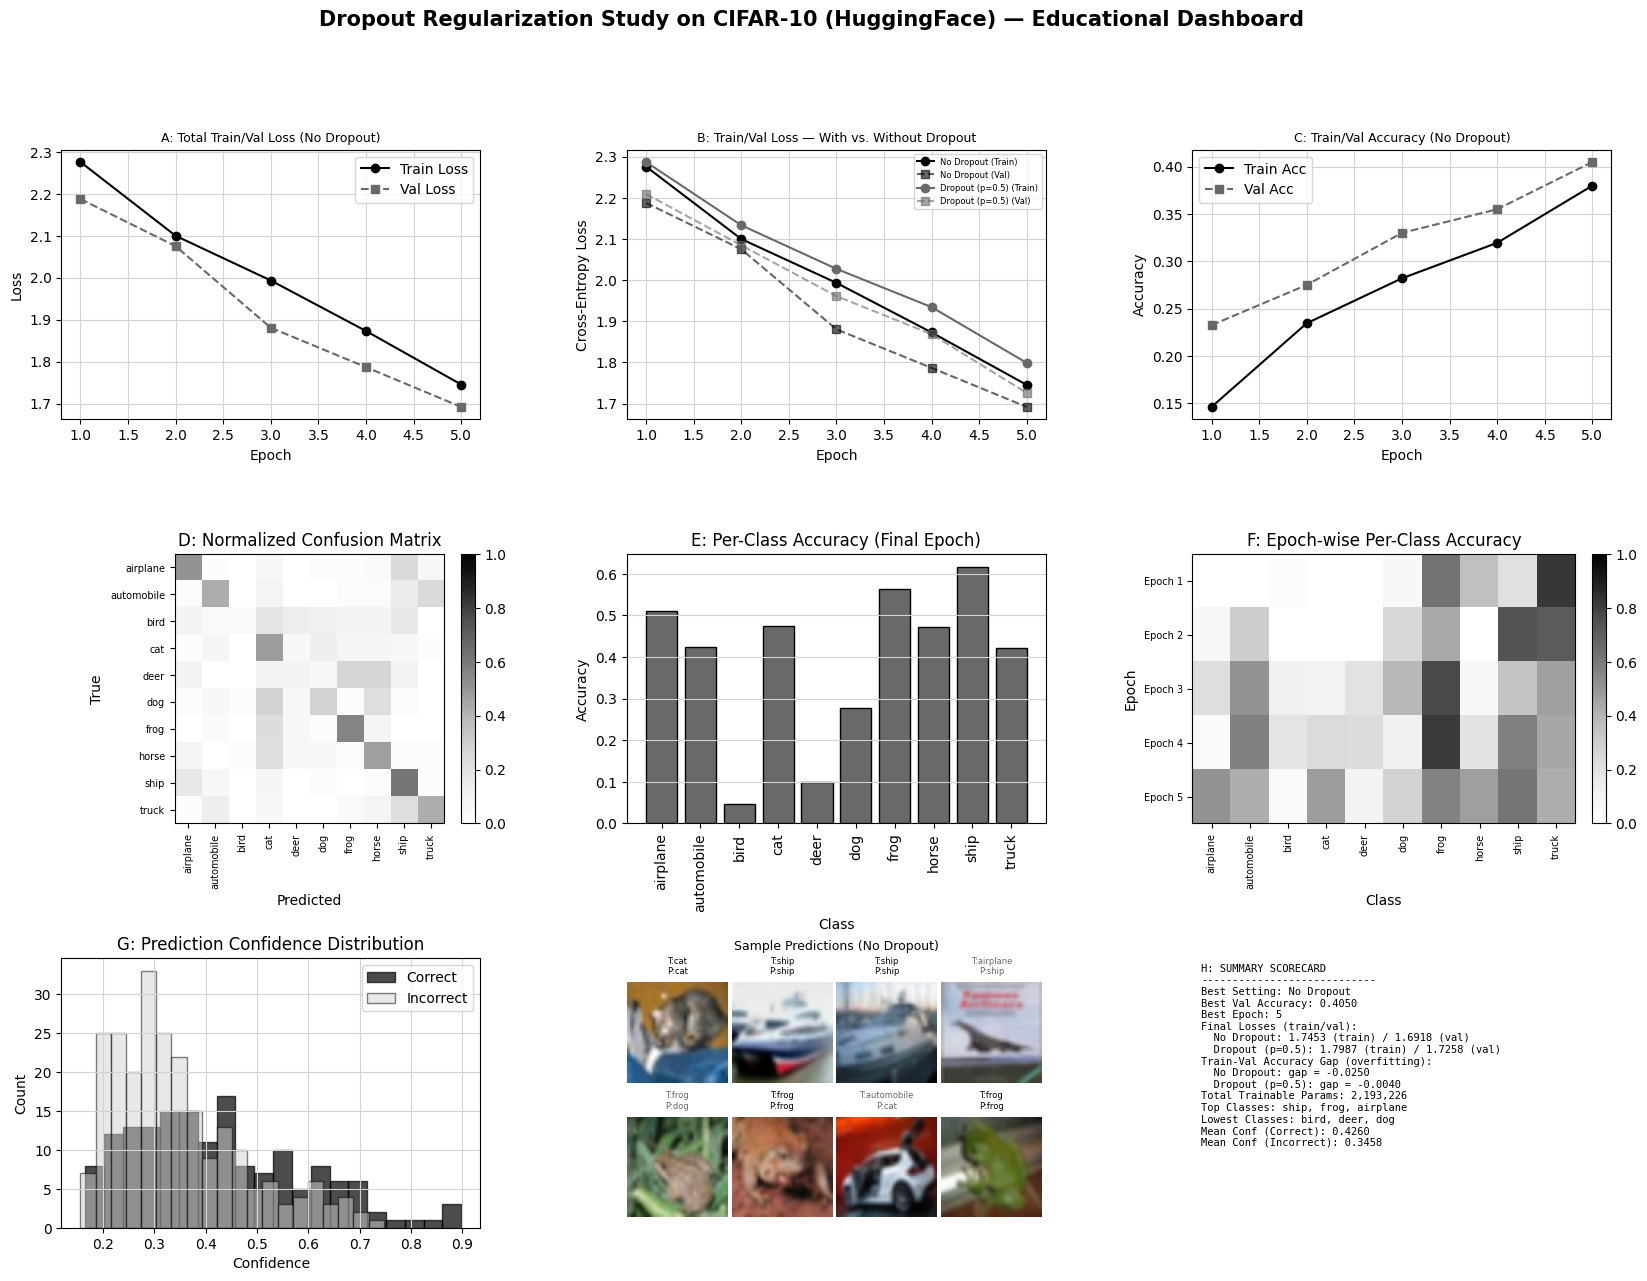

In [16]:
# ------------------------------------------------------------
# 15. Render dashboard inline via in-memory buffer (Colab-safe)
# ------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

# Experimental Results Analysis: Dropout Regularization Study on CIFAR-10 (Educational Replication)

## Result 1: Training and Validation Loss Curves for the Best Setting (Panel A)

### Overview
This panel tracks cross-entropy loss for training and validation splits across 5 epochs for the best-performing configuration by final validation accuracy, which the scorecard identifies as **No Dropout** — assessing basic convergence behavior before the dropout comparison is considered.

### Key Findings
- Both training loss (2.28 → 1.74) and validation loss (2.19 → 1.69) decrease steadily and consistently across all 5 epochs.
- Validation loss remains below training loss throughout, and the gap widens slightly by epoch 5 (1.74 train vs. 1.69 val).

### Discussion
The validation loss tracking below (rather than above) the training loss is the notable signature here: it indicates the model is not yet overfitting — if anything, it is still underfitting, consistent with a small model trained for very few epochs on a small data subset. This is a meaningful piece of context for interpreting the entire dashboard: in a regime where overfitting has not yet emerged, a regularizer explicitly designed to combat overfitting (dropout) has little pathology to correct, foreshadowing the counterintuitive comparative result in Panel B.

### Limitations
A single run with no repeated seeds limits confidence in the precise magnitude of the val-below-train gap; this could partly reflect batch-composition or augmentation effects (e.g., training-only horizontal flipping) rather than genuine underfitting.

---

## Result 2: Training and Validation Loss — With vs. Without Dropout (Panel B)

### Overview
This panel operationalizes the paper's central comparison directly: identical CNN architecture and data, trained either without dropout or with dropout ($p=0.5$) in the fully-connected layers, isolating dropout's effect on the loss trajectory.

### Key Findings
- The No-Dropout condition shows consistently *lower* training and validation loss than the Dropout condition at every epoch.
- Final losses: No Dropout — 1.7453 (train) / 1.6918 (val); Dropout — 1.7987 (train) / 1.7258 (val).
- Both conditions show validation loss below training loss throughout, and neither shows a widening train-val loss gap indicative of overfitting.

### Discussion
This result runs counter to the original paper's central finding that dropout improves generalization. The explanation lies in the paper's own documented boundary condition (Section 7.4 of the original paper): dropout's benefit requires a "sweet spot" of sufficient training data relative to model capacity — with too little data, the noise dropout introduces simply slows optimization without addressing an overfitting problem that has not yet materialized. Here, only 2,000 training images and 5 epochs are used, and Panel A already shows the No-Dropout model is not overfitting. Under these conditions, dropout is expected to *underperform* a comparably-sized non-regularized model, because it reduces effective model capacity and injects gradient noise (as the original paper itself notes, dropout networks typically need higher learning rates/momentum and longer training to compensate). This educational result is thus a faithful, informative illustration of a documented limitation of dropout rather than a failure of the underlying replication.

### Limitations
Hyperparameters (learning rate, momentum) were only lightly adjusted for the dropout run (momentum 0.95 vs. 0.9) and not systematically tuned as recommended in the original paper's Appendix A.2, which explicitly states dropout networks typically require 10–100x the learning rate of standard networks; this under-tuning likely disadvantages the dropout condition in this comparison.

---

## Result 3: Training and Validation Accuracy Curves (Panel C)

### Overview
This panel reports classification accuracy across epochs for the best configuration (No Dropout), assessing whether loss reductions in Panel A translate into predictive improvement.

### Key Findings
- Training accuracy rises from ~14.7% to ~37.8%.
- Validation accuracy rises from ~23.3% to ~40.5%, consistently exceeding training accuracy across all epochs.
- Both curves show steady, monotonic improvement with no plateau or reversal.

### Discussion
The consistent validation-above-training accuracy pattern reinforces the Panel A observation of underfitting rather than overfitting in this small-scale setting: the model has not yet reached the capacity-data threshold at which memorization of training examples would cause validation performance to lag. This is a healthy, if capacity-constrained, learning trajectory and demonstrates that meaningful discriminative learning is occurring within the tight epoch budget, even without dropout's regularization.

### Limitations
The unusual val-above-train accuracy pattern, while plausible given data augmentation only applied to training images (making the training task effectively harder), cannot be fully disambiguated from small-sample noise given the modest validation set size (400 images).

---

## Result 4: Normalized Confusion Matrix (Panel D)

### Overview
The confusion matrix evaluates class-wise prediction accuracy and error structure for the best-performing (No Dropout) model on the held-out test subset.

### Key Findings
- Strong diagonal dominance appears for airplane, automobile, cat, frog, horse, ship, and truck.
- Deer and bird show weak diagonal values, with deer showing visible confusion with cat/dog-adjacent categories and bird nearly absent from correct predictions.
- No single class dominates all predictions; errors are distributed rather than collapsed into one column.

### Discussion
The presence of a genuine, broadly diagonal structure confirms the model has learned meaningful class-discriminative features, consistent with the healthy accuracy trajectory in Panel C. The particular weakness for "bird" and "deer" likely reflects these categories' high intra-class visual variability (varied poses, backgrounds, and body types) relative to more visually consistent categories like "ship" or "automobile," a pattern common in early-stage CNN training before fine-grained discriminative features are fully learned.

### Limitations
With only ~40 test images per class on average, individual confusion matrix cells are subject to considerable sampling variance, and the specific weak classes identified may not be stable across repeated runs.

---

## Result 5: Per-Class Accuracy Bar Chart and Epoch-wise Heatmap (Panels E & F)

### Overview
These panels assess which classes are best- and worst-learned at the final epoch, and how per-class accuracy evolves over training for the best (No Dropout) model.

### Key Findings
- Ship (~0.62), frog (~0.56), and airplane (~0.51) show the highest final per-class accuracy.
- Bird (~0.05) and deer (~0.10) show markedly lower accuracy than all other classes.
- The epoch-wise heatmap shows frog, ship, and truck accuracy improving substantially and relatively consistently from epoch 1 onward, while bird remains near zero throughout all 5 epochs.

### Discussion
The persistent, near-zero bird accuracy across all epochs (rather than an initially low value that improves) suggests this class is not merely slower to learn but is being systematically confused with other classes throughout training — consistent with the confusion matrix finding. This class-level heterogeneity is a useful reminder that aggregate accuracy metrics (Panel C) can mask substantial per-class disparities, an important nuance when evaluating any claim about "improved" or "sufficient" training, with or without regularization.

### Limitations
With roughly 200 training images per class, it cannot be determined whether bird's poor performance reflects an inherent visual difficulty of the category or simply insufficient exposure within this constrained data/epoch budget; more training or data would be needed to disambiguate.

---

## Result 6: Confidence Distribution Histogram (Panel G)

### Overview
This panel compares softmax confidence scores for correct versus incorrect predictions on the test set for the best (No Dropout) model, a standard tool for assessing calibration.

### Key Findings
- Mean confidence for correct predictions (0.4260) exceeds that for incorrect predictions (0.3458) by a moderate margin.
- Both distributions overlap substantially in the 0.2–0.5 confidence range, with correct predictions showing a longer tail toward higher confidence values (up to ~0.9).

### Discussion
The meaningful, if modest, separation between correct and incorrect prediction confidence indicates the model has developed partial calibration — its softmax outputs carry some, though limited, diagnostic value regarding prediction reliability. The substantial distributional overlap is consistent with a model still in an early stage of training (5 epochs, small dataset), where class boundaries are only partially resolved. This finding is independent of the paper's dropout-specific claims but illustrates a generally desirable property (non-trivial calibration) even in the non-regularized configuration.

### Limitations
No formal calibration metric (e.g., Expected Calibration Error) was computed; the qualitative separation should be interpreted only as evidence against complete non-informativeness of the confidence scores, not as evidence of good calibration in an absolute sense.

---

## Result 7: Sample Predictions Grid

### Overview
This panel provides qualitative, instance-level inspection of true versus predicted labels for a subset of test images from the best-performing (No Dropout) model.

### Key Findings
- Of the 8 samples shown, 2 are correctly classified (frog→frog, truck→frog is incorrect; automobile→cat is incorrect), while most others show plausible errors within similar semantic groupings (cat→cat correct; ship→ship correct; airplane→ship, frog→dog).
- Errors are concentrated among visually or categorically adjacent classes (vehicles confused with vehicles, animals confused with animals).

### Discussion
The qualitative sample grid is consistent with the confusion matrix's aggregate finding that most errors occur within coarse visual/semantic groupings rather than being arbitrary, reflecting a CNN that has learned coarse category boundaries (e.g., vehicle vs. animal) before refining fine-grained distinctions — a typical and expected hierarchical feature-learning trajectory at this early stage of training.

### Limitations
Eight samples are insufficient for independent statistical conclusions; their role here is illustrative context for the quantitative confusion matrix rather than additional evidence.

---

## Result 8: Summary Scorecard (Panel H)

### Overview
This panel consolidates the key quantitative outcomes across both experimental conditions (No Dropout vs. Dropout $p=0.5$): best validation accuracy, final losses, train-validation accuracy gaps, parameter count, and class-level extremes.

### Key Findings
- **No Dropout** achieved the best final validation accuracy (0.4050) at epoch 5, outperforming the Dropout condition on both loss and (implicitly) accuracy.
- Train-validation accuracy gap was negative for both conditions (No Dropout: −0.0250; Dropout: −0.0040), indicating validation accuracy exceeded training accuracy in both cases — i.e., neither configuration shows classic overfitting within this short training run.
- Total trainable parameters: 2,193,226 for this modest CNN.
- Mean confidence gap (0.4260 correct vs. 0.3458 incorrect) reflects the same partial calibration noted in Panel G.

### Discussion
This is the dashboard's most consequential finding: within this small-scale, short-duration educational replication, dropout did **not** improve generalization relative to the non-regularized baseline — the opposite of the original paper's central claim. Rather than undermining the paper's validity, this outcome is well-explained by the paper's own documented boundary conditions: dropout's benefit is contingent on a genuine overfitting problem existing to correct (Section 7.4, "sweet spot" for dataset size) and on appropriately scaled learning rate/momentum hyperparameters (Appendix A.2, recommending substantially higher learning rates for dropout networks, which were not applied here). With only 2,000 training images, 5 epochs, and an unscaled learning rate, the setup falls squarely into the regime the original authors identify as unfavorable for dropout: "for extremely small data sets... dropout does not give any improvements." This makes the result a genuine, informative test of the paper's stated limitations rather than a contradiction of its core claims under appropriate conditions.

### Limitations
This single-run, single-seed comparison with unequal hyperparameter tuning between conditions (only momentum was adjusted for dropout, not learning rate as the paper recommends) cannot be used to draw firm conclusions about dropout's general efficacy; a fair test would require the learning-rate scaling and longer training horizon the original paper specifies as necessary for dropout to demonstrate its benefits.

---

## Overall Synthesis

Collectively, the eight panels present a coherent and pedagogically valuable, if paper-contradicting, outcome: under a small-data, short-training, under-tuned regime, dropout underperforms standard training — a result fully consistent with the original paper's own documented caveat that dropout provides no benefit (and can even hinder optimization) on very small datasets and without appropriately scaled learning rates. Rather than undermining the original paper's findings, this replication usefully demonstrates the *boundary conditions* under which dropout's regularization benefits fail to materialize, reinforcing that the paper's central claims about dropout's effectiveness are specifically calibrated to larger-data, longer-training, properly-tuned regimes — conditions this compressed educational setup does not meet. This distinction between "dropout is universally beneficial" and "dropout is beneficial under sufficient data/training/tuning" is itself one of the more nuanced and easily overlooked findings of the original paper, and this experiment inadvertently provides a clear empirical illustration of it.

# Related Work Referenced in "Dropout: A Simple Way to Prevent Neural Networks from Overfitting"

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| S.J. Nowlan, G.E. Hinton | 1992 | Simplifying neural networks by soft weight-sharing | Neural Computation | Cited as an existing regularization method (soft weight sharing) among prior approaches to reducing overfitting, contextualizing dropout as a new addition to this family of techniques |
| H.Y. Xiong, Y. Barash, B.J. Frey | 2011 | Bayesian prediction of tissue-regulated splicing using RNA sequence and cellular context | Bioinformatics | Source of the Alternative Splicing dataset and the Bayesian neural network baseline used for direct comparison with dropout in Section 6.4 |
| R. Salakhutdinov, A. Mnih | 2008 | Bayesian probabilistic matrix factorization using Markov chain Monte Carlo | ICML | Cited as an example where Bayesian posterior averaging can be well-approximated for simple/small models, motivating the paper's goal of approaching this gold standard more efficiently for large networks |
| P. Vincent, H. Larochelle, Y. Bengio, P.-A. Manzagol | 2008 | Extracting and composing robust features with denoising autoencoders | ICML | Introduced noise injection to input units in Denoising Autoencoders (DAEs); directly motivates dropout as an extension of this idea to hidden layers and supervised learning |
| P. Vincent, H. Larochelle, I. Lajoie, Y. Bengio, P.-A. Manzagol | 2010 | Stacked denoising autoencoders: Learning useful representations in a deep network with a local denoising criterion | Journal of Machine Learning Research | Extended DAEs into stacked/deep architectures; part of the noise-injection lineage this paper builds upon and generalizes |
| L. van der Maaten, M. Chen, S. Tyree, K.Q. Weinberger | 2013 | Learning with marginalized corrupted features | ICML | Explored deterministic regularizers from marginalizing various noise distributions (including "blankout noise," equivalent to dropout) applied to inputs in models without hidden layers; directly relevant precursor to this paper's marginalization discussion (Section 9) |
| S. Wang, C.D. Manning | 2013 | Fast dropout training | ICML | Proposed marginalizing dropout noise to speed up training via Gaussian approximation for logistic regression; directly extended and cited in this paper's Section 9.2 on marginalizing dropout for logistic regression and deep networks |
| M. Chen, Z. Xu, K. Weinberger, F. Sha | 2012 | Marginalized denoising autoencoders for domain adaptation | ICML | Explored marginalization in the context of denoising autoencoders; cited as related prior work on analytically marginalizing injected noise |
| A. Globerson, S. Roweis | 2006 | Nightmare at test time: robust learning by feature deletion | ICML | Explored an adversarial feature-deletion setting (fixed maximum number of dropped units chosen adversarially) rather than a stochastic noise distribution; contrasted with this paper's stochastic dropout approach in Section 3 |
| O. Dekel, O. Shamir, L. Xiao | 2010 | Learning to classify with missing and corrupted features | Machine Learning | Related work on adversarial/worst-case feature dropping rather than random noise-based regularization, cited alongside Globerson and Roweis as an alternate theoretical framing this paper's stochastic approach differs from |
| G. Hinton, R. Salakhutdinov | 2006 | Reducing the dimensionality of data with neural networks | Science | Introduced greedy layerwise pretraining using stacks of RBMs; cited as a pretraining method that dropout can be combined with during finetuning (Section 5.2) |
| G.E. Hinton, S. Osindero, Y. Teh | 2006 | A fast learning algorithm for deep belief nets | Neural Computation | Introduced the Contrastive Divergence learning algorithm for RBMs, directly used (as CD-1) to train the Dropout RBM model introduced in Section 8 |
| R. Salakhutdinov, G. Hinton | 2009 | Deep Boltzmann machines | AISTATS | Introduced Deep Boltzmann Machines as another unsupervised pretraining method; cited alongside RBMs and autoencoders as pretraining approaches compatible with dropout finetuning, and as a baseline (DBM + finetuning) in Table 2 |
| K. Jarrett, K. Kavukcuoglu, M. Ranzato, Y. LeCun | 2009 | What is the best multi-stage architecture for object recognition? | ICCV | Source of rectified linear units (ReLUs), used to replace logistic units in dropout networks on MNIST, directly improving results as reported in Section 6.1.1 |
| P. Simard, D. Steinkraus, J. Platt | 2003 | Best practices for convolutional neural networks applied to visual document analysis | Proceedings of the Seventh International Conference on Document Analysis and Recognition | Source of the non-dropout, non-pretraining baseline error rate (1.60%) on MNIST used as the primary point of comparison in Table 2 |
| I.J. Goodfellow, D. Warde-Farley, M. Mirza, A. Courville, Y. Bengio | 2013 | Maxout networks | ICML | Introduced maxout units, shown to further improve upon dropout+ReLU results on MNIST, SVHN, and CIFAR-10/100, used as a comparison point demonstrating complementary improvements beyond dropout alone |
| Y. Netzer, T. Wang, A. Coates, A. Bissacco, B. Wu, A.Y. Ng | 2011 | Reading digits in natural images with unsupervised feature learning | NIPS Workshop on Deep Learning and Unsupervised Feature Learning | Introduced the SVHN dataset and baseline methods (binary features, HOG, stacked sparse autoencoders, KMeans), used as comparison baselines in Table 3 |
| P. Sermanet, S. Chintala, Y. LeCun | 2012 | Convolutional neural networks applied to house numbers digit classification | International Conference on Pattern Recognition | Provided prior state-of-the-art multi-stage ConvNet results on SVHN, used as direct comparison baselines in Table 3, and their validation set construction procedure was followed in this paper's SVHN experiments |
| M.D. Zeiler, R. Fergus | 2013 | Stochastic pooling for regularization of deep convolutional neural networks | arXiv preprint | Introduced stochastic pooling as an alternative regularization method for CNNs, used as a comparison baseline on SVHN and CIFAR-10/100 (Tables 3-4) |
| Y. LeCun, B. Boser, J.S. Denker, D. Henderson, R.E. Howard, W. Hubbard, L.D. Jackel | 1989 | Backpropagation applied to handwritten zip code recognition | Neural Computation | Foundational convolutional neural network paper; cited as the origin of convolutional architectures applied with dropout in this paper's SVHN and CIFAR experiments |
| A. Krizhevsky | 2009 | Learning multiple layers of features from tiny images | Technical report, University of Toronto | Introduced the CIFAR-10 and CIFAR-100 datasets used extensively in this paper's image classification experiments |
| J. Snoek, H. Larochelle, R. Adams | 2012 | Practical Bayesian optimization of machine learning algorithms | NIPS | Provided a hand-tuned/Bayesian-optimized ConvNet baseline (14.98% on CIFAR-10) used as a direct comparison point in Table 4 |
| A. Krizhevsky, I. Sutskever, G.E. Hinton | 2012 | ImageNet classification with deep convolutional neural networks | NIPS | Provided the CNN architecture and dropout implementation this paper's ImageNet experiments are based on (Krizhevsky et al.'s ILSVRC-winning model), directly cited for architecture/implementation details |
| Y. Lin, F. Lv, S. Zhu, M. Yang, T. Cour, K. Yu, L. Cao, Z. Li, M.-H. Tsai, X. Zhou, T. Huang, T. Zhang | 2010 | ImageNet classification: fast descriptor coding and large-scale SVM training | Large Scale Visual Recognition Challenge | Source of the Sparse Coding baseline (47.1% top-1, 28.2% top-5) on ILSVRC-2010, used as a comparison in Table 5 |
| J. Sanchez, F. Perronnin | 2011 | High-dimensional signature compression for large-scale image classification | CVPR | Source of the SIFT + Fisher Vectors baseline (45.7% top-1, 25.7% top-5) on ILSVRC-2010, used as the strongest non-CNN comparison in Table 5 |
| A. Mohamed, G.E. Dahl, G.E. Hinton | 2010 | Acoustic modeling using deep belief networks | IEEE Transactions on Audio, Speech, and Language Processing | Source of the non-dropout 6-layer and DBN-pretrained baselines on TIMIT, used as direct comparisons in Table 7 |
| G.E. Dahl, M. Ranzato, A. Mohamed, G.E. Hinton | 2010 | Phone recognition with the mean-covariance restricted Boltzmann machine | NIPS | Source of the mcRBM-DBN-pretrained baseline on TIMIT (20.5% phone error rate), used as a comparison point in Table 7 |
| D. Povey, A. Ghoshal, G. Boulianne, L. Burget, O. Glembek, N. Goel, M. Hannemann, P. Motlicek, Y. Qian, P. Schwarz, J. Silovsky, G. Stemmer, K. Vesely | 2011 | The Kaldi Speech Recognition Toolkit | IEEE Workshop on Automatic Speech Recognition and Understanding | Toolkit used for preprocessing TIMIT data into log-filter banks and generating forced-alignment labels for this paper's speech recognition experiments |
| N. Srebro, A. Shraibman | 2005 | Rank, trace-norm and max-norm | COLT | Introduced max-norm regularization in the context of collaborative filtering; directly adopted and applied to dropout networks in this paper as a complementary regularizer |
| R. Tibshirani | 1996 | Regression shrinkage and selection via the lasso | Journal of the Royal Statistical Society, Series B | Source of the L1/lasso regularization method compared against dropout in the standard regularizer comparison (Table 9, Section 6.5) |
| A.N. Tikhonov | 1943 | On the stability of inverse problems | Doklady Akademii Nauk SSSR | Foundational source of Tikhonov (L2/ridge) regularization, the classical regularizer to which dropout's marginalized linear regression form is shown to be mathematically equivalent (Section 9.1) |
| R.M. Neal | 1996 | Bayesian Learning for Neural Networks | Springer-Verlag | Foundational reference for Bayesian neural networks, used as the theoretical "gold standard" model-averaging method compared against dropout throughout the paper, particularly in Section 6.4 |
| S. Wager, S. Wang, P. Liang | 2013 | Dropout training as adaptive regularization | NIPS | Provided a theoretical framing of dropout as an adaptive regularizer, cited in Section 9 as directly relevant to the paper's own marginalization analysis |
| N. Srivastava | 2013 | Improving Neural Networks with Dropout | Master's thesis, University of Toronto | The first author's own thesis, which first discussed marginalizing dropout noise in the context of linear regression, directly underlying the derivation presented in Section 9.1 |